### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")    #apre un file csv in read mode
df.columns  #mi stampa il nome di tutte le colonne
df.sort_values(by = "total_litres_of_pure_alcohol", ascending = False).head(10) #ordina per colonna, in ordine decrescente, solo i primi 10

df["beer_servings"].values  #ritorna i soli valori
media_birra = df["beer_servings"].mean()  #calcola la media
media_vino = df["wine_servings"].mean()
media_distillati = df["spirit_servings"].mean()

df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"])/3   #creo una nuova colonna

df[df["alcohol_index"] == df["alcohol_index"].max()]["country"]  #prendo il paese con il massimo

df[df["beer_servings"]>100] #tutti i paesi che consumano più di 100 birre l'anno



,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
5,Antigua & Barbuda,102,128,45,4.9,91.666667
6,Argentina,193,25,221,8.3,146.333333
8,Australia,261,72,212,10.4,181.666667
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,180.000000
184,USA,249,158,84,8.7,163.666667
185,Uruguay,115,35,220,6.6,123.333333
188,Venezuela,333,100,3,7.7,145.333333


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [ ]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

year_salary = df.groupby("job_country")["salary_year_avg"].mean()   #calcolo la media del salario annuale per ogni paese

job_count = df.groupby("job_country").count() #conta il numero di offerte di lavoro

max = df.groupby("job_country")["salary_year_avg"].max()
min = df.groupby("job_country")["salary_year_avg"].min()
print(f'{year_salary}, {job_count}, \n{max}, {min}')


job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64,              job_title_short  job_title  job_location  job_via  \
job_country                                                      
Afghanistan               16         16            16       16   
Albania                  119        119           119      119   
Algeria                  111        111           111      111   
Angola                    11         11            11       11   
Argentina               8736       8736          8736     8736   
...                      ...        ...           ...      ...   
Venezuela                 69         69            69       69   
Vietnam                

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

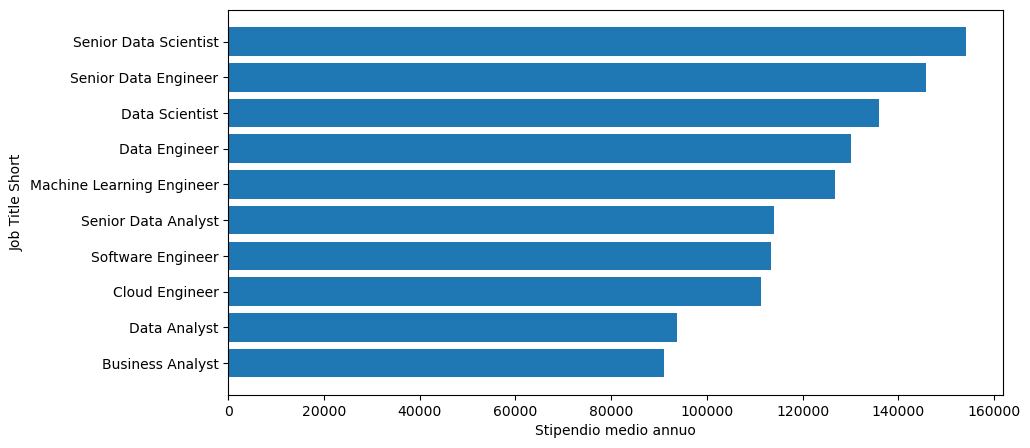

In [ ]:
import matplotlib.pyplot as plt

job_title = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending = False)
plt.figure(figsize = (10, 5))
plt.barh(job_title.index, job_title.values)
plt.ylabel("Job Title Short")
plt.xlabel("Stipendio medio annuo")
plt.gca().invert_yaxis()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

conto_medio = df.groupby("day")["total_bill"].mean()    #fa la media dei conti per giorno

num_righe = df.groupby("day").count()   #conto il numero di rigeh per giorno

conto_max = df.groupby("day")["total_bill"].max()   #trovo il conto massimo per giorno
conto_min = df.groupby("day")["total_bill"].min()   #trovo il conto minimo per giorno

df["conto_per_persona"] = df["total_bill"]/df["size"]   #aggiungo una nuova colonna

df[df["total_bill"] == conto_medio.max()]

print(conto_min, conto_max)

print(conto_medio[conto_medio == conto_medio.max()])  #stampo il giorno con il conto medio maggiore

df.head()

day
Fri     5.75
Sat     3.07
Sun     7.25
Thur    7.51
Name: total_bill, dtype: float64 day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64


day
Sun    21.41
Name: total_bill, dtype: float64

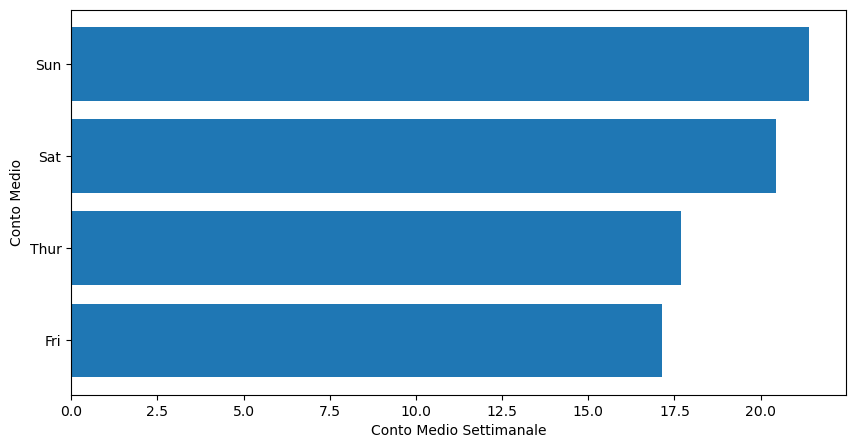

In [50]:
conto_medio = conto_medio.sort_values(ascending = False)
plt.figure(figsize = (10, 5))
plt.barh(conto_medio.index, conto_medio.values)
plt.ylabel("Conto Medio")
plt.xlabel("Conto Medio Settimanale")
plt.gca().invert_yaxis()
plt.show()